# Maize Disease Classification with EfficientNetB0

##  Dataset Setup

In [8]:
from google.colab import drive
drive.mount('/content/drive')

print("✅ Setup complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup complete!


## Import Libraries

In [9]:
import tensorflow as tf
from keras import layers, models, optimizers, applications
# from keras.applications import EfficientNetB0, efficientnet
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import pathlib
import random
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from IPython.display import display, HTML

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# Enable mixed precision for better performance
tf.keras.mixed_precision.set_global_policy('mixed_float16')

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

✅ Libraries imported successfully!
TensorFlow version: 2.18.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Configuration and Dataset Path

In [10]:
# Configuration
CONFIG = {
    'img_size': (224, 224),
    'batch_size': 32,
    'initial_lr': 1e-3,
    'fine_tune_lr': 1e-4,
    'initial_epochs': 20,
    'fine_tune_epochs': 20,
    'dropout_rate': 0.2,
    'test_split': 0.1,
    'val_split': 0.1
}

# Dataset path - UPDATE THIS PATH TO YOUR DATASET
BASE_DIR = pathlib.Path('/content/drive/MyDrive/maize_leaf_dataset')

# Verify dataset exists
if not BASE_DIR.exists():
    print(f"❌ Dataset not found at: {BASE_DIR}")
    print("Please update the BASE_DIR path to your dataset location")
else:
    print(f"✅ Dataset found at: {BASE_DIR}")
    # Show dataset structure
    subdirs = [d.name for d in BASE_DIR.iterdir() if d.is_dir()]
    print(f"Classes found: {subdirs}")

    # Count images per class
    for subdir in subdirs:
        img_count = len(list((BASE_DIR / subdir).glob('*')))
        print(f"  {subdir}: {img_count} images")

✅ Dataset found at: /content/drive/MyDrive/maize_leaf_dataset
Classes found: ['Gray Leaf Spot', 'Not Maize Leaf', 'Common Rust', 'Healthy', 'Northern Leaf Blight']
  Gray Leaf Spot: 1642 images
  Not Maize Leaf: 1536 images
  Common Rust: 1907 images
  Healthy: 1859 images
  Northern Leaf Blight: 1931 images


## Helper Functions

In [11]:
def preprocess_image(file_path, label, img_size, num_classes):
    """Load and preprocess a single image"""
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32)
    img = applications.efficientnet.preprocess_input(img)
    label = tf.one_hot(label, num_classes)
    return img, label

def create_dataset(paths, labels, img_size, num_classes, batch_size=32,
                  augment=False, cache=True):
    """Create optimized tf.data.Dataset"""
    AUTOTUNE = tf.data.AUTOTUNE

    # Convert to lists and ensure proper types
    paths = list(paths)  # Convert tuple to list
    labels = list(labels)  # Convert tuple to list

    # Create dataset from tensor slices
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    # Map preprocessing function
    ds = ds.map(
        lambda x, y: preprocess_image(x, y, img_size, num_classes),
        num_parallel_calls=AUTOTUNE
    )

    if augment:
        augmentation = tf.keras.Sequential([
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.1),
        ])
        ds = ds.shuffle(1000, seed=42)
        ds = ds.map(
            lambda x, y: (augmentation(x, training=True), y),
            num_parallel_calls=AUTOTUNE
        )

    ds = ds.batch(batch_size)
    if cache:
        ds = ds.cache()
    ds = ds.prefetch(AUTOTUNE)

    return ds

def build_model(img_size, num_classes, dropout_rate=0.2):
    """Build EfficientNetB0 transfer learning model"""
    base_model = applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=img_size + (3,)
    )
    base_model.trainable = False

    inputs = layers.Input(shape=img_size + (3,))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    return models.Model(inputs, outputs), base_model

print("✅ Helper functions defined!")

✅ Helper functions defined!


## Load and Split Dataset

In [12]:
print("Loading dataset...")

# Gather image paths and labels
all_image_paths = [str(p) for p in BASE_DIR.glob('*/*') if p.is_file()]
if not all_image_paths:
    raise ValueError(f"No images found in {BASE_DIR}")

label_names = sorted([d.name for d in BASE_DIR.iterdir() if d.is_dir()])
label_to_index = {name: idx for idx, name in enumerate(label_names)}
all_labels = [label_to_index[pathlib.Path(p).parent.name] for p in all_image_paths]

# Shuffle and split
data = list(zip(all_image_paths, all_labels))
random.shuffle(data)
paths, labels = zip(*data)

n_total = len(paths)
n_train = int((1 - CONFIG['test_split'] - CONFIG['val_split']) * n_total)
n_val = int(CONFIG['val_split'] * n_total)

# Create splits
train_paths, train_labels = paths[:n_train], labels[:n_train]
val_paths, val_labels = paths[n_train:n_train + n_val], labels[n_train:n_train + n_val]
test_paths, test_labels = paths[n_train + n_val:], labels[n_train + n_val:]

num_classes = len(label_names)

print(f"✅ Dataset loaded successfully!")
print(f"Classes ({num_classes}): {label_names}")
print(f"Train: {len(train_paths)} images")
print(f"Validation: {len(val_paths)} images")
print(f"Test: {len(test_paths)} images")

Loading dataset...
✅ Dataset loaded successfully!
Classes (5): ['Common Rust', 'Gray Leaf Spot', 'Healthy', 'Northern Leaf Blight', 'Not Maize Leaf']
Train: 7100 images
Validation: 887 images
Test: 888 images


## Create TensorFlow Datasets

Creating TensorFlow datasets...
Train paths type: <class 'tuple'>, length: 7100
Train labels type: <class 'tuple'>, length: 7100
Sample path: /content/drive/MyDrive/maize_leaf_dataset/Not Maize Leaf/NotMaizeLeaf (124).JPG
Sample label: 4
✅ Datasets created successfully!
Sample batch shapes - Images: (32, 224, 224, 3), Labels: (32, 5)


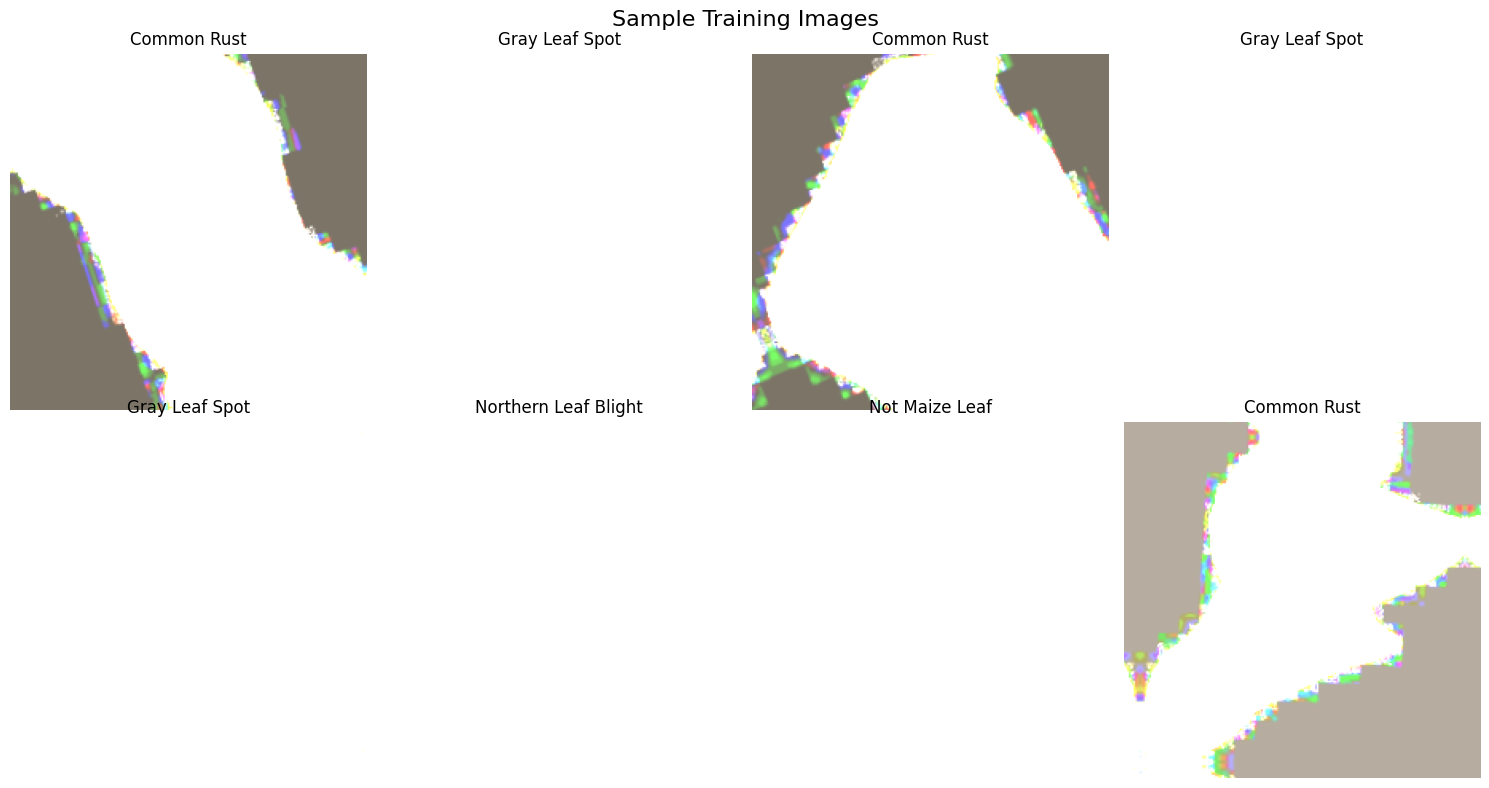

In [13]:
print("Creating TensorFlow datasets...")

# Debug: Check data types and shapes
print(f"Train paths type: {type(train_paths)}, length: {len(train_paths)}")
print(f"Train labels type: {type(train_labels)}, length: {len(train_labels)}")
print(f"Sample path: {train_paths[0]}")
print(f"Sample label: {train_labels[0]}")

try:
    # Create datasets
    train_ds = create_dataset(
        train_paths, train_labels,
        CONFIG['img_size'], num_classes,
        CONFIG['batch_size'], augment=True
    )

    val_ds = create_dataset(
        val_paths, val_labels,
        CONFIG['img_size'], num_classes,
        CONFIG['batch_size']
    )

    test_ds = create_dataset(
        test_paths, test_labels,
        CONFIG['img_size'], num_classes,
        CONFIG['batch_size']
    )

    print("✅ Datasets created successfully!")

    # Test dataset by taking one batch
    sample_batch = next(iter(train_ds))
    print(f"Sample batch shapes - Images: {sample_batch[0].shape}, Labels: {sample_batch[1].shape}")

    # Visualize some sample images with proper preprocessing for display
    plt.figure(figsize=(15, 8))
    images, labels = sample_batch

    for i in range(min(8, len(images))):
        plt.subplot(2, 4, i + 1)

        # Get the preprocessed image
        img = images[i].numpy()

        # Reverse EfficientNet preprocessing for proper display
        # EfficientNet preprocessing: (img - mean) / std where mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        # We need to reverse this normalization
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        # Reverse normalization
        img = img * std + mean

        # Clip values to valid range [0, 1]
        img = np.clip(img, 0, 1)

        # Convert to proper dtype for matplotlib
        img = img.astype(np.float32)

        plt.imshow(img)
        class_idx = tf.argmax(labels[i]).numpy()
        plt.title(f'{label_names[class_idx]}')
        plt.axis('off')

    plt.suptitle('Sample Training Images', fontsize=16)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ Error creating datasets: {e}")
    print("Debugging information:")
    print(f"Paths sample: {train_paths[:3] if len(train_paths) > 0 else 'Empty'}")
    print(f"Labels sample: {train_labels[:3] if len(train_labels) > 0 else 'Empty'}")

    # Let's try a simpler approach
    print("\nTrying alternative dataset creation...")

    # Convert to numpy arrays first
    train_paths_array = np.array(train_paths, dtype=str)
    train_labels_array = np.array(train_labels, dtype=np.int32)

    print(f"Array shapes - Paths: {train_paths_array.shape}, Labels: {train_labels_array.shape}")

    # Create dataset with explicit types
    train_ds = tf.data.Dataset.from_tensor_slices({
        'path': train_paths_array,
        'label': train_labels_array
    })

    def preprocess_dict(data):
        return preprocess_image(data['path'], data['label'], CONFIG['img_size'], num_classes)

    train_ds = train_ds.map(preprocess_dict, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.batch(CONFIG['batch_size']).cache().prefetch(tf.data.AUTOTUNE)

    print("✅ Alternative dataset creation successful!")

## Build and Compile Model

In [14]:
print("Building model...")

# Build model
model, base_model = build_model(CONFIG['img_size'], num_classes, CONFIG['dropout_rate'])

# Compile for initial training
model.compile(
    optimizer=optimizers.Adam(learning_rate=CONFIG['initial_lr']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

print(f"✅ Model built successfully!")

Building model...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_1 (Cast)                   │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

✅ Model built successfully!


##  Initial Training (Frozen Base)

In [15]:
print("Starting initial training with frozen base model...")

# Setup callbacks
callbacks = [
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        verbose=1
    )
]

# Train
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG['initial_epochs'],
    callbacks=callbacks,
    verbose=1
)

print("✅ Initial training completed!")

Starting initial training with frozen base model...
Epoch 1/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8289 - loss: 0.5747
Epoch 1: val_accuracy improved from -inf to 0.96843, saving model to best_model.keras
222/222 ━━━━━━━━━━━━━━━━━━━━ 676s 3s/step - accuracy: 0.8293 - loss: 0.5735 - val_accuracy: 0.9684 - val_loss: 0.1354 - learning_rate: 0.0010
Epoch 2/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9699 - loss: 0.1100
Epoch 2: val_accuracy improved from 0.96843 to 0.97407, saving model to best_model.keras
222/222 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - accuracy: 0.9699 - loss: 0.1100 - val_accuracy: 0.9741 - val_loss: 0.0974 - learning_rate: 0.0010
Epoch 3/20
220/222 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9737 - loss: 0.0846
Epoch 3: val_accuracy did not improve from 0.97407
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9736 - loss: 0.0847 - val_accuracy: 0.9741 - val_loss: 0.0851 - learning_rate: 0.0010
Epoch 4/20
220/222 ━━━━━━━━━━━━━━━━━

## Fine-tuning

In [16]:
print("Starting fine-tuning...")

# Unfreeze last 20 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

print(f"Trainable layers: {sum([1 for layer in base_model.layers if layer.trainable])}")
print(f"Trainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")

# Recompile with lower learning rate
model.compile(
    optimizer=optimizers.Adam(learning_rate=CONFIG['fine_tune_lr']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
# fine_tune_callbacks  = ModelCheckpoint(
#     'best_model', # Remove .h5 extension for SavedModel format
#     monitor='val_accuracy',
#     save_best_only=True,
#     verbose=1
# )

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG['initial_epochs'] + CONFIG['fine_tune_epochs'],
    initial_epoch=CONFIG['initial_epochs'],
    callbacks=callbacks,
    verbose=1
)

print("✅ Fine-tuning completed!")

Starting fine-tuning...
Trainable layers: 20
Trainable parameters: 1,357,365
Epoch 21/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9705 - loss: 0.0924
Epoch 21: val_accuracy did not improve from 0.98309
222/222 ━━━━━━━━━━━━━━━━━━━━ 64s 144ms/step - accuracy: 0.9705 - loss: 0.0924 - val_accuracy: 0.9786 - val_loss: 0.0623 - learning_rate: 1.0000e-04
Epoch 22/40
221/222 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9855 - loss: 0.0393
Epoch 22: val_accuracy did not improve from 0.98309
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9855 - loss: 0.0393 - val_accuracy: 0.9831 - val_loss: 0.0560 - learning_rate: 1.0000e-04
Epoch 23/40
220/222 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9949 - loss: 0.0177
Epoch 23: val_accuracy did not improve from 0.98309
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9949 - loss: 0.0177 - val_accuracy: 0.9808 - val_loss: 0.0545 - learning_rate: 1.0000e-04
Epoch 24/40
220/222 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accurac

## Plot Training History

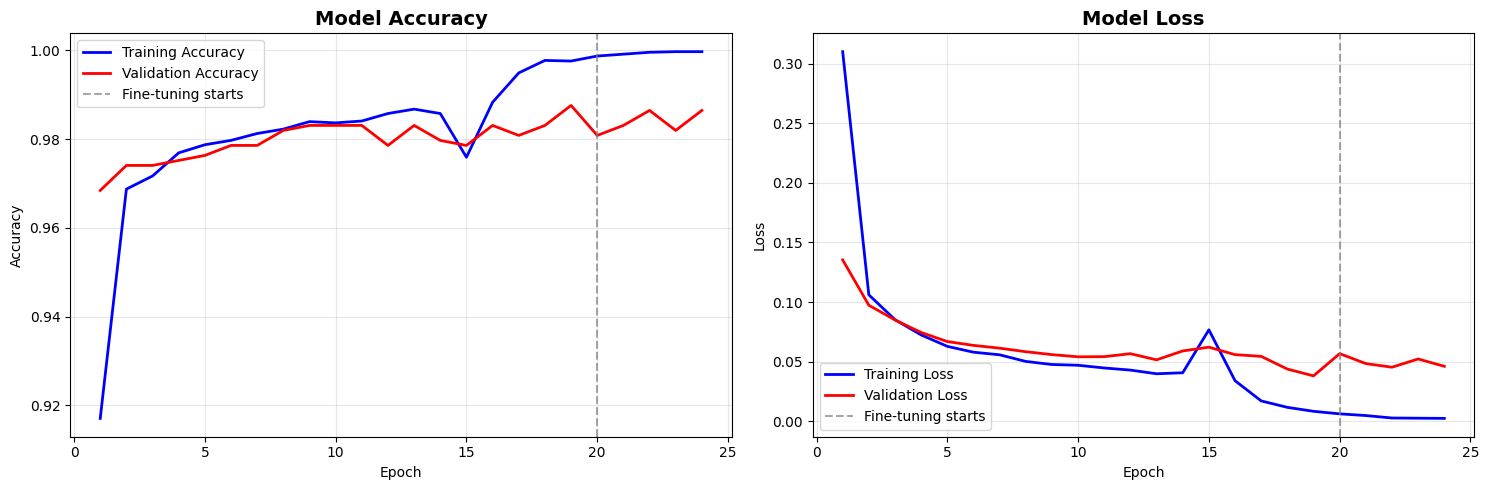

Best validation accuracy: 0.9876 at epoch 19


In [17]:
def plot_training_history(history1, history2):
    """Plot training metrics"""
    acc = history1.history['accuracy'] + history2.history['accuracy']
    val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss = history1.history['loss'] + history2.history['loss']
    val_loss = history1.history['val_loss'] + history2.history['val_loss']

    epochs = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy plot
    ax1.plot(epochs, acc, 'b-', label='Training Accuracy', linewidth=2)
    ax1.plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
    ax1.axvline(x=CONFIG['initial_epochs'], color='gray', linestyle='--', alpha=0.7, label='Fine-tuning starts')
    ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss plot
    ax2.plot(epochs, loss, 'b-', label='Training Loss', linewidth=2)
    ax2.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
    ax2.axvline(x=CONFIG['initial_epochs'], color='gray', linestyle='--', alpha=0.7, label='Fine-tuning starts')
    ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print best metrics
    best_val_acc = max(val_acc)
    best_val_acc_epoch = val_acc.index(best_val_acc) + 1
    print(f"Best validation accuracy: {best_val_acc:.4f} at epoch {best_val_acc_epoch}")

plot_training_history(history1, history2)

## Model Evaluation

In [18]:
print("Evaluating model on test set...")

# Load best model
best_model = tf.keras.models.load_model('best_model.keras')

# Get predictions
y_pred_probs = best_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels
y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds])

# Overall accuracy
test_accuracy = np.mean(y_true == y_pred)
print(f"\n🎯 Test Accuracy: {test_accuracy:.4f}")

# Classification report
print("\n📊 Classification Report:")
report = classification_report(y_true, y_pred, target_names=label_names, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(3)
display(report_df)

Evaluating model on test set...
28/28 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step

🎯 Test Accuracy: 0.9786

📊 Classification Report:


,precision,recall,f1-score,support
Common Rust,1.000,0.996,0.998,224.000
Gray Leaf Spot,0.974,0.914,0.943,163.000
Healthy,1.000,1.000,1.000,182.000
Northern Leaf Blight,0.920,0.977,0.948,176.000
Not Maize Leaf,1.000,1.000,1.000,143.000
accuracy,0.979,0.979,0.979,0.979
macro avg,0.979,0.977,0.978,888.000
weighted avg,0.979,0.979,0.979,888.000


## Confusion Matrix Visualization

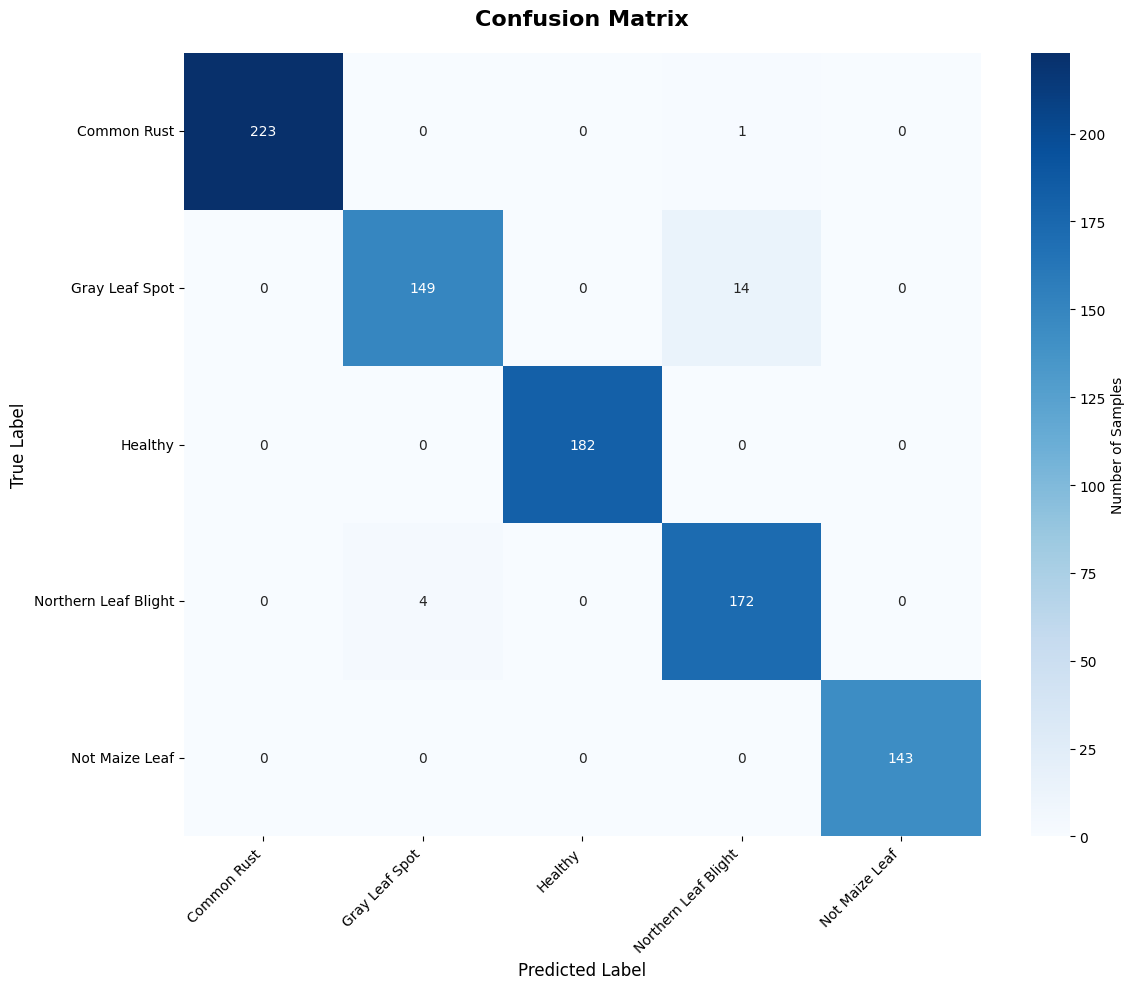


📈 Per-class Accuracy:
  Common Rust: 0.996
  Gray Leaf Spot: 0.914
  Healthy: 1.000
  Northern Leaf Blight: 0.977
  Not Maize Leaf: 1.000


In [19]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_names,
    yticklabels=label_names,
    cmap='Blues',
    cbar_kws={'label': 'Number of Samples'}
)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class accuracy
class_accuracies = cm.diagonal() / cm.sum(axis=1)
print("\n📈 Per-class Accuracy:")
for i, (class_name, acc) in enumerate(zip(label_names, class_accuracies)):
    print(f"  {class_name}: {acc:.3f}")

## Sample Predictions Visualization

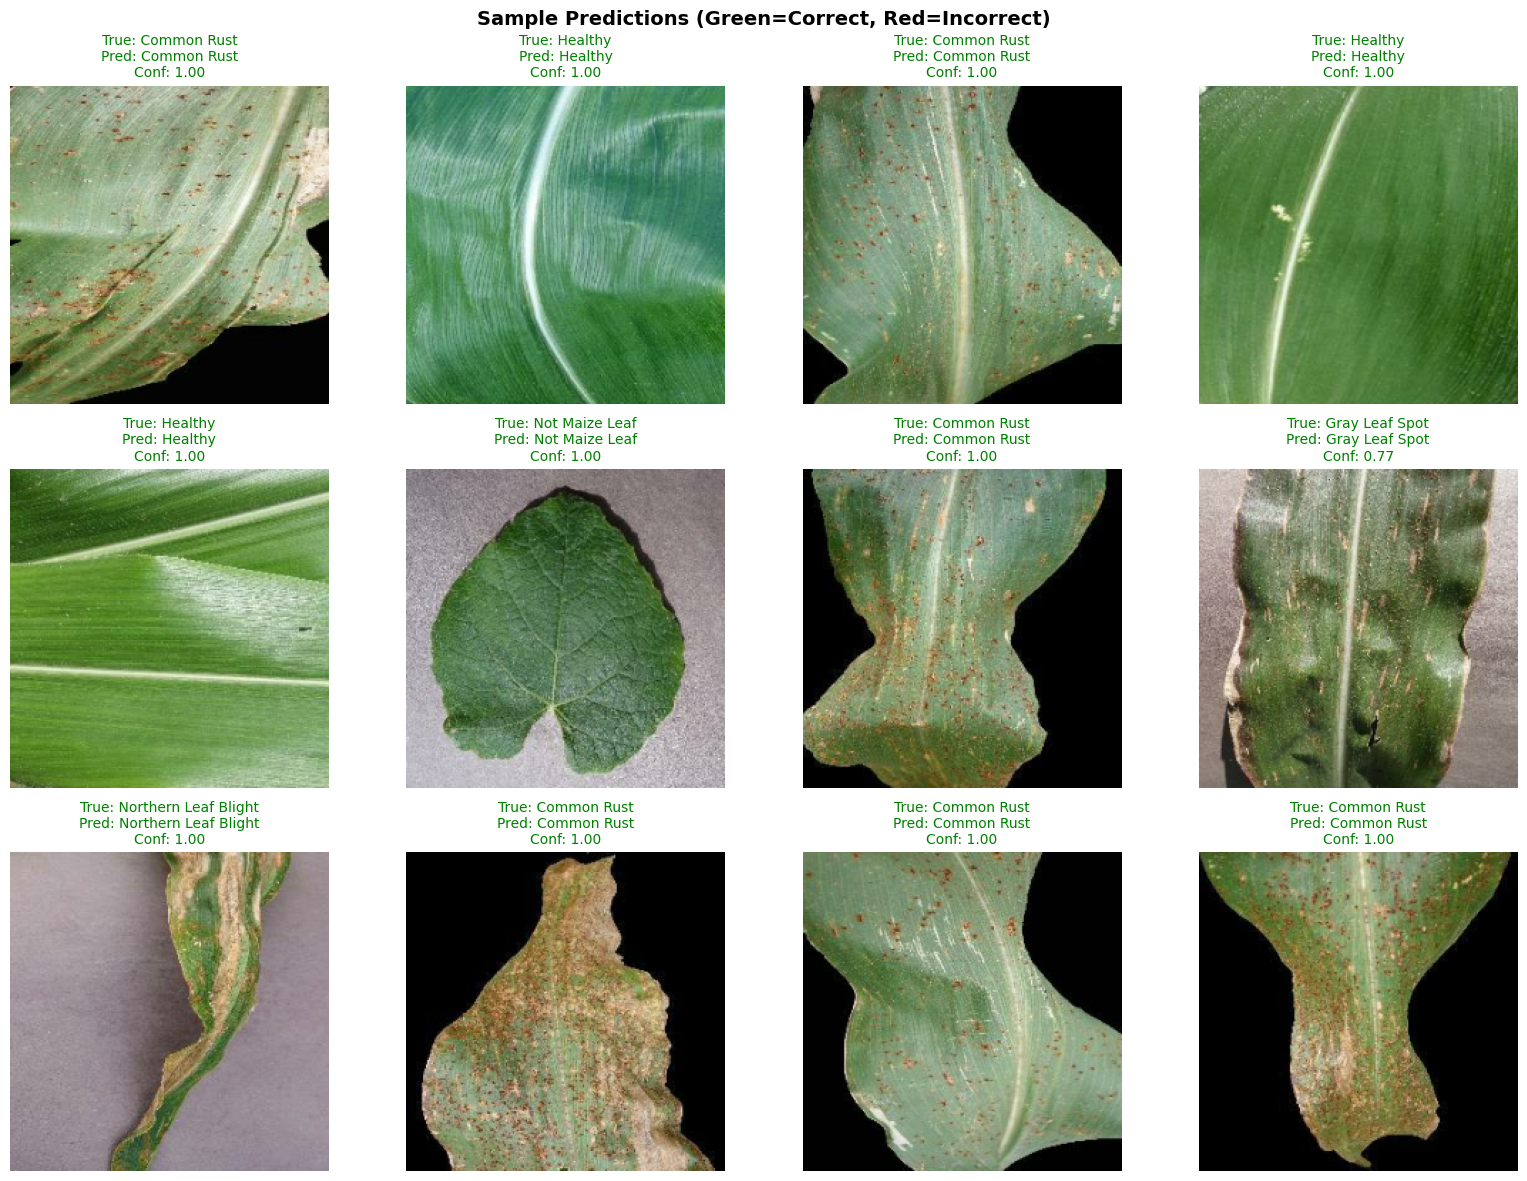

In [20]:
# Visualize sample predictions
def plot_predictions(model, test_ds, label_names, num_samples=12):
    # Get a batch of test images
    for images, labels in test_ds.take(1):
        predictions = model.predict(images, verbose=0)

        plt.figure(figsize=(16, 12))
        for i in range(min(num_samples, len(images))):
            plt.subplot(3, 4, i + 1)

            # Process image for display
            img = images[i].numpy()
            img_min, img_max = img.min(), img.max()
            if img_max > img_min:
                img = (img - img_min) / (img_max - img_min)
            plt.imshow(img)

            true_class = label_names[tf.argmax(labels[i]).numpy()]
            pred_class = label_names[np.argmax(predictions[i])]
            confidence = np.max(predictions[i])

            # Color coding: green for correct, red for incorrect
            color = 'green' if true_class == pred_class else 'red'

            plt.title(f'True: {true_class}\nPred: {pred_class}\nConf: {confidence:.2f}',
                     color=color, fontsize=10)
            plt.axis('off')

        plt.suptitle('Sample Predictions (Green=Correct, Red=Incorrect)',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        break

plot_predictions(best_model, test_ds, label_names)

## Convert to TensorFlow Lite

In [22]:
print("Converting model to TensorFlow Lite...")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Optional: Add representative dataset for better quantization
def representative_dataset():
    for images, _ in train_ds.take(100):
        for i in range(images.shape[0]):
            yield [images[i:i+1]]

converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

# Save TFLite model
tflite_path = 'maize_classifier.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

# Model size comparison
original_size = os.path.getsize('best_model.keras') / (1024 * 1024)  # MB
tflite_size = os.path.getsize(tflite_path) / (1024 * 1024)  # MB

print(f"✅ TensorFlow Lite model saved!")
print(f"Original model size: {original_size:.2f} MB")
print(f"TFLite model size: {tflite_size:.2f} MB")
print(f"Size reduction: {((original_size - tflite_size) / original_size * 100):.1f}%")

Converting model to TensorFlow Lite...
Saved artifact at '/tmp/tmpqy6_f538'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  135842832438224: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  135843113823952: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  135843113823568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135843113824912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135843113825872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135843113825104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135843113824144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135843113825680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135843113827216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135843113828176: TensorSpe

## Test TensorFlow Lite Model

In [23]:
# Test TFLite model performance
def test_tflite_model(tflite_path, test_ds, num_samples=100):
    # Load TFLite model
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    predictions = []
    true_labels = []

    sample_count = 0
    for images, labels in test_ds:
        if sample_count >= num_samples:
            break

        for i in range(len(images)):
            if sample_count >= num_samples:
                break

            # Prepare input
            input_data = np.expand_dims(images[i], axis=0)
            interpreter.set_tensor(input_details[0]['index'], input_data)

            # Run inference
            interpreter.invoke()

            # Get output
            output_data = interpreter.get_tensor(output_details[0]['index'])
            predictions.append(np.argmax(output_data))
            true_labels.append(np.argmax(labels[i]))

            sample_count += 1

    # Calculate accuracy
    accuracy = np.mean(np.array(predictions) == np.array(true_labels))
    return accuracy

tflite_accuracy = test_tflite_model(tflite_path, test_ds)
print(f"TensorFlow Lite model accuracy: {tflite_accuracy:.4f}")
print(f"Original model accuracy: {test_accuracy:.4f}")
print(f"Accuracy difference: {abs(test_accuracy - tflite_accuracy):.4f}")

TensorFlow Lite model accuracy: 0.9700
Original model accuracy: 0.9786
Accuracy difference: 0.0086


## Save Results and Summary

In [24]:
# Create summary report
summary = {
    'Model': 'EfficientNetB0 Transfer Learning',
    'Dataset Classes': len(label_names),
    'Class Names': label_names,
    'Total Images': len(all_image_paths),
    'Train Images': len(train_paths),
    'Validation Images': len(val_paths),
    'Test Images': len(test_paths),
    'Initial Epochs': CONFIG['initial_epochs'],
    'Fine-tune Epochs': CONFIG['fine_tune_epochs'],
    'Best Validation Accuracy': max(history1.history['val_accuracy'] + history2.history['val_accuracy']),
    'Test Accuracy': test_accuracy,
    'TFLite Accuracy': tflite_accuracy,
    'Model Size (MB)': original_size,
    'TFLite Size (MB)': tflite_size
}

print("🎉 TRAINING COMPLETE!")
print("=" * 60)
for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    elif isinstance(value, list):
        print(f"{key}: {', '.join(value)}")
    else:
        print(f"{key}: {value}")
print("=" * 60)

# Save summary to file
import json
with open('training_summary.json', 'w') as f:
    # Convert numpy types to native Python types for JSON serialization
    json_summary = {}
    for k, v in summary.items():
        if isinstance(v, np.floating):
            json_summary[k] = float(v)
        elif isinstance(v, np.integer):
            json_summary[k] = int(v)
        else:
            json_summary[k] = v
    json.dump(json_summary, f, indent=2)

print("\n📁 Files saved:")
print("  - best_model_finetuned.h5 (Keras model)")
print("  - maize_classifier.tflite (TensorFlow Lite model)")
print("  - training_summary.json (Training summary)")

print(f"\n🎯 Final Results Summary:")
print(f"  - Classes: {len(label_names)} ({', '.join(label_names)})")
print(f"  - Test Accuracy: {test_accuracy:.1%}")
print(f"  - Model Size Reduction: {((original_size - tflite_size) / original_size * 100):.1f}%")

🎉 TRAINING COMPLETE!
Model: EfficientNetB0 Transfer Learning
Dataset Classes: 5
Class Names: Common Rust, Gray Leaf Spot, Healthy, Northern Leaf Blight, Not Maize Leaf
Total Images: 8875
Train Images: 7100
Validation Images: 887
Test Images: 888
Initial Epochs: 20
Fine-tune Epochs: 20
Best Validation Accuracy: 0.9876
Test Accuracy: 0.9786
TFLite Accuracy: 0.9700
Model Size (MB): 37.0249
TFLite Size (MB): 7.8216

📁 Files saved:
  - best_model_finetuned.h5 (Keras model)
  - maize_classifier.tflite (TensorFlow Lite model)
  - training_summary.json (Training summary)

🎯 Final Results Summary:
  - Classes: 5 (Common Rust, Gray Leaf Spot, Healthy, Northern Leaf Blight, Not Maize Leaf)
  - Test Accuracy: 97.9%
  - Model Size Reduction: 78.9%
